# 04 — Single-Variable Composite Explorer

Interactive notebook for exploring **any** variable (or sum of variables)
from the composite-blocking NPZ archive.

**Two modes**:
1. **2-panel** (default): composite mean + bootstrap significance (hatched non-sig)
2. **6-panel** (`projection=True`): adds 2×2 projection onto dh−1 orthogonal basis
   (INT, PRP, DEF, Residual) using **only significant** grid points, with
   β, αx, αy, γ in the subtitle.

Data: `/net/flood/data2/users/x_yan/composite_blocking_tempest/onset`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from functools import partial

from pvtend.plotting import (
    plot_var as _plot_var_src,
    get_field,
    load_events as _load_events_src,
    bootstrap_sig,
)

## 1  Configuration & available fields

In [2]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
LEVEL      = 200 #"wavg"            # "wavg" or int hPa (e.g. 200, 250)
SMOOTH_DEG = 3.0
GRID_SP    = 1.5
N_BOOT     = 500
ALPHA      = 0.05
SEED       = 42
PV_CONTOUR = - 0 * 0.5e-6     # PV anomaly contour for mask boundary
N_CONTOUR  = 21          # number of contourf levels

# ═══════════════════════════════════════════════════════════
#  Projection masking config (toggle on/off)
# ═══════════════════════════════════════════════════════════
USE_SIG_MASK    = True   # zero out non-significant pixels before projection
MASK_SPEC = "< 0"   # restrict basis to q' < 0 region (mask)

# ── Discover available fields and levels from a sample NPZ ──
_sample = np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/" +
                  sorted(os.listdir(f"{DATA_ROOT}/{STAGE}/dh=+0"))[0])
levels_hpa = _sample["levels"]          # isobaric levels
wavg_levels = _sample["wavg_levels"]    # levels used for wavg

# Separate 2D (wavg) vs 3D fields
_all_keys = sorted(_sample.keys())
_meta = {"X_rel", "Y_rel", "levels", "wavg_levels", "center_lat", "center_lon",
         "center_mode", "dh", "lat0", "lat_vec", "lon0", "lon_vec_unwrapped",
         "track_id", "ts", "G0", "H_SCALE"}
fields_wavg = sorted(k for k in _all_keys
                     if _sample[k].ndim == 2 and not k.endswith("_3d") and k not in _meta)
fields_3d   = sorted(k for k in _all_keys if k.endswith("_3d"))

print(f"LEVEL = {LEVEL}")
print(f"Isobaric levels (hPa): {levels_hpa}")
print(f"Wavg levels   (hPa) : {wavg_levels}")
print(f"\n── 2D wavg fields ({len(fields_wavg)}) ──")
for f in fields_wavg:
    print(f"  {f}")
print(f"\n── 3D isobaric fields ({len(fields_3d)}) ──")
for f in fields_3d[:10]:
    print(f"  {f}")
print(f"  ... ({len(fields_3d)} total)")
print(f"\n  USE_SIG_MASK={USE_SIG_MASK}  USE_NEG_PV_MASK={USE_NEG_PV_MASK}")

del _sample

LEVEL = 200
Isobaric levels (hPa): [1000  850  700  500  400  300  250  200  100]
Wavg levels   (hPa) : [300 250 200]

── 2D wavg fields (109) ──
  Q
  pv
  pv_anom
  pv_anom_dp
  pv_anom_dt
  pv_anom_dx
  pv_anom_dy
  pv_bar
  pv_bar_dp
  pv_bar_dt
  pv_bar_dx
  pv_bar_dy
  pv_dp
  pv_dx
  pv_dy
  q
  t
  t_dt
  theta
  theta_dot
  theta_dt
  u
  u_anom
  u_anom_pv_anom_dx
  u_anom_pv_bar_dx
  u_bar
  u_bar_pv_anom_dx
  u_bar_pv_bar_dx
  u_div
  u_div_anom
  u_div_anom_pv_anom_dx
  u_div_anom_pv_bar_dx
  u_div_bar
  u_div_bar_pv_anom_dx
  u_div_bar_pv_bar_dx
  u_div_dry
  u_div_dry_pv_anom_dx
  u_div_dry_pv_bar_dx
  u_div_emanuel_moist
  u_div_emanuel_moist_pv_anom_dx
  u_div_emanuel_moist_pv_bar_dx
  u_div_moist
  u_div_moist_pv_anom_dx
  u_div_moist_pv_bar_dx
  u_div_qg_moist
  u_div_qg_moist_pv_anom_dx
  u_div_qg_moist_pv_bar_dx
  u_har_anom
  u_rot
  u_rot_anom
  u_rot_anom_pv_anom_dx
  u_rot_anom_pv_bar_dx
  u_rot_bar
  u_rot_bar_pv_anom_dx
  u_rot_bar_pv_bar_dx
  v
  v_anom
  v_

## 2  Bind `pvtend.plotting` to notebook config

In [3]:
# ═══════════════════════════════════════════════════════════
#  Bind notebook config to src functions — existing calls work unchanged
# ═══════════════════════════════════════════════════════════
plot_var = partial(
    _plot_var_src,
    data_root=DATA_ROOT, stage=STAGE, level=LEVEL,
    smooth_deg=SMOOTH_DEG, grid_sp=GRID_SP,
    n_boot=N_BOOT, alpha=ALPHA, seed=SEED,
    pv_contour=PV_CONTOUR, n_contour=N_CONTOUR,
    use_sig_mask=USE_SIG_MASK, mask=MASK_SPEC,
)
load_events = partial(_load_events_src, data_root=DATA_ROOT, stage=STAGE)

print("plot_var / load_events bound to notebook config via pvtend.plotting")

plot_var / load_events bound to notebook config via pvtend.plotting


## 3  `plot_var` ready

In [4]:
# plot_var() now lives in pvtend.plotting.composite_explorer
# Bound to notebook config above — all example calls below work unchanged.
# Override any param per-call, e.g. plot_var(["u_bar"], dh=0, level=500)
print(f"plot_var ready — DATA_ROOT=...{DATA_ROOT[-30:]}, STAGE={STAGE}, LEVEL={LEVEL}")

plot_var ready — DATA_ROOT=...yan/composite_blocking_tempest, STAGE=onset, LEVEL=200


## 4  Examples

Computing bootstrap (N=1131, n_boot=500) ...
  26.6% significant at 95%


/net/flood/data2/users/x_yan/pvtend/src/pvtend/plotting/composite_explorer.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


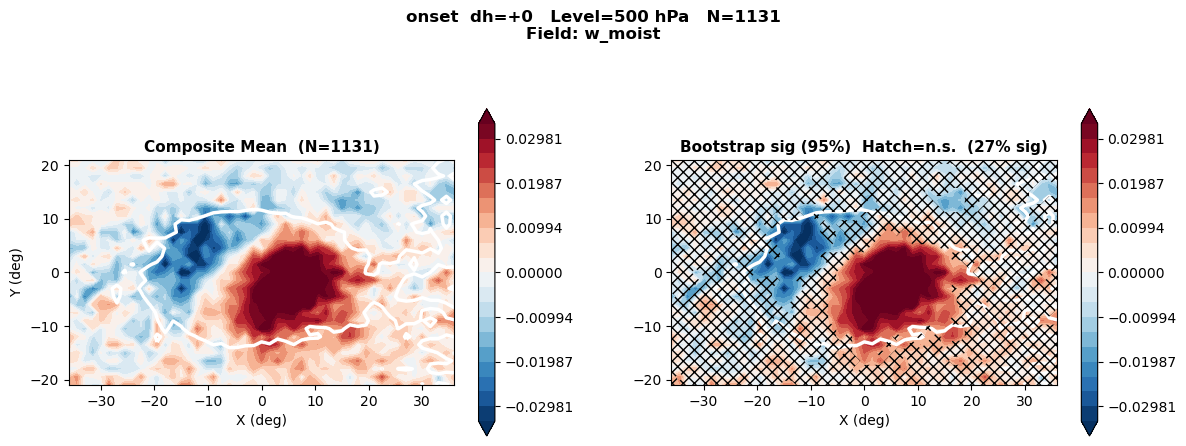

{'vmax': np.float64(0.033119889210576056)}

In [5]:
plot_var(["w_moist"], dh=0, level=500, projection = False)

Computing bootstrap (N=1136, n_boot=500) ...
  55.0% significant at 95%


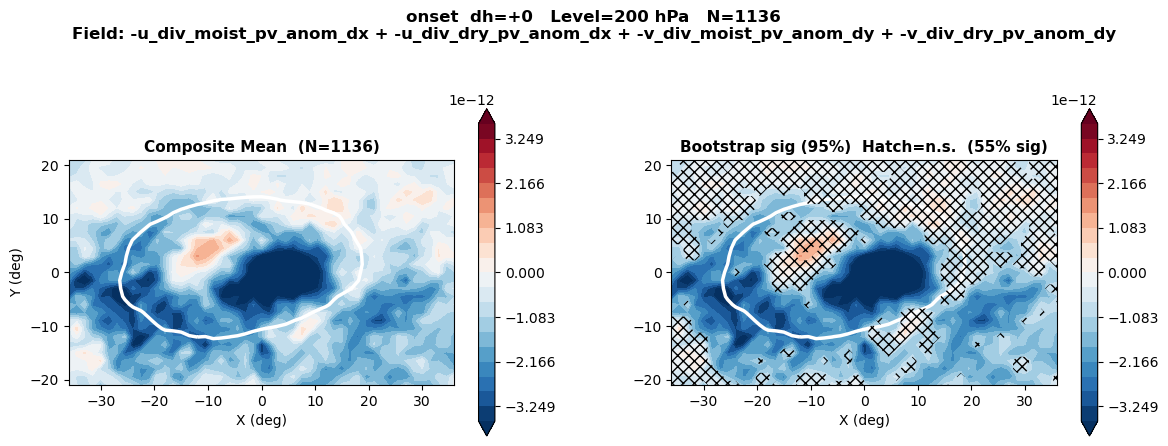

{'vmax': np.float64(3.609947688058841e-12)}

In [6]:
# 6-panel: divergent outflow (no projection)
plot_var(["-u_div_moist_pv_anom_dx", "-u_div_dry_pv_anom_dx", "-v_div_moist_pv_anom_dy", "-v_div_dry_pv_anom_dy"], dh=0, level=200, projection=False)

Computing bootstrap (N=1221, n_boot=500) ...
  100.0% significant at 95%


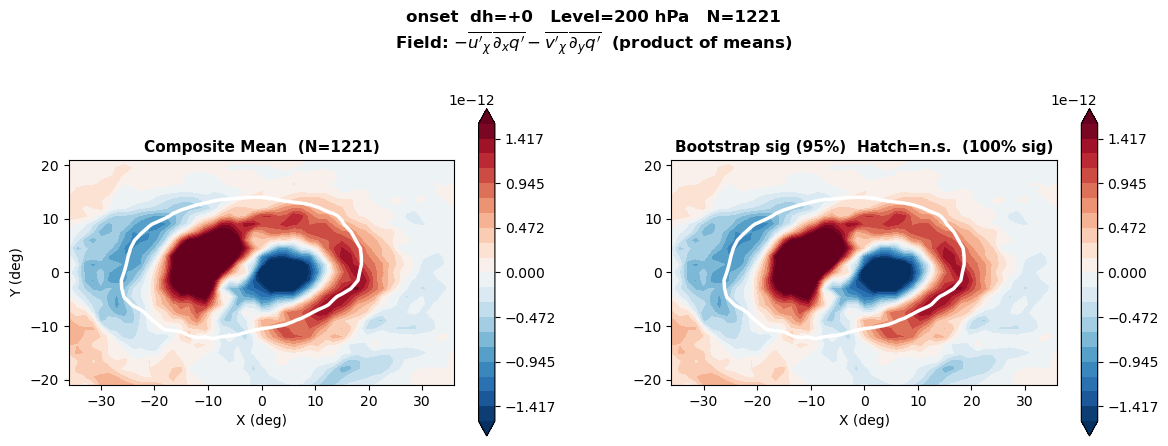

{'vmax': np.float64(1.5748915576736363e-12)}

In [22]:
# product-of-means: mean(u'_div) * mean(dq'/dx) + mean(v'_div) * mean(dq'/dy)
# differs from mean(u'_div * dq'/dx) by the covariance / eddy-eddy term
evs = load_events(dh=0)
_stack = lambda name: np.array([get_field(e, name, 200) for e in evs])
mean_u = np.nanmean(_stack("u_div_anom"), axis=0)
mean_v = np.nanmean(_stack("v_div_anom"), axis=0)
mean_dqdx = np.nanmean(_stack("pv_anom_dx"), axis=0)
mean_dqdy = np.nanmean(_stack("pv_anom_dy"), axis=0)
prod_of_means = -(mean_u * mean_dqdx + mean_v * mean_dqdy)

plot_var(
    lambda e: prod_of_means,   # constant — shows product-of-composite-means
    dh=0, level=200, projection=False,
    label=(r"$-\overline{u'_\chi}\,\overline{\partial_x q'}"
           r" - \overline{v'_\chi}\,\overline{\partial_y q'}$"
           "  (product of means)"),
)

## Some horizontal wind fields

Computing bootstrap (N=1175, n_boot=500) ...
  75.1% significant at 95%


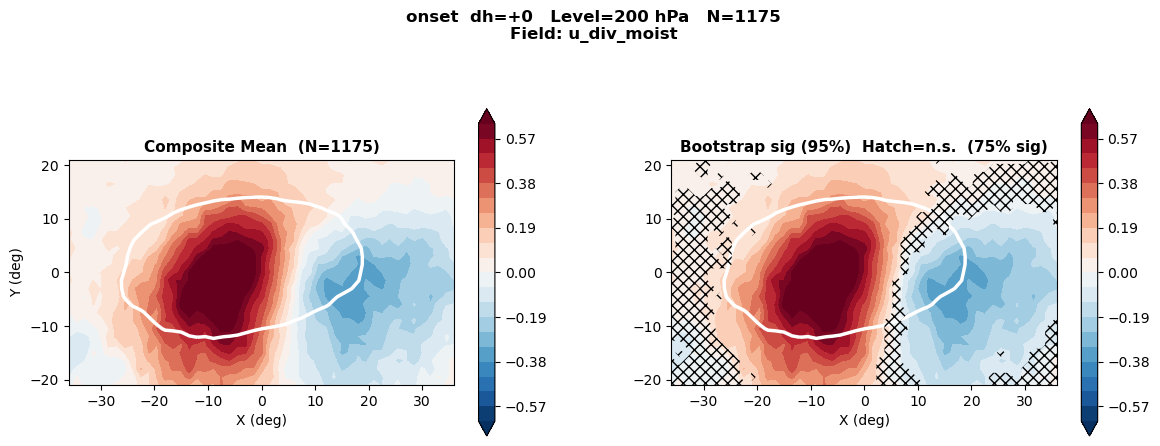

Computing bootstrap (N=1176, n_boot=500) ...
  88.5% significant at 95%


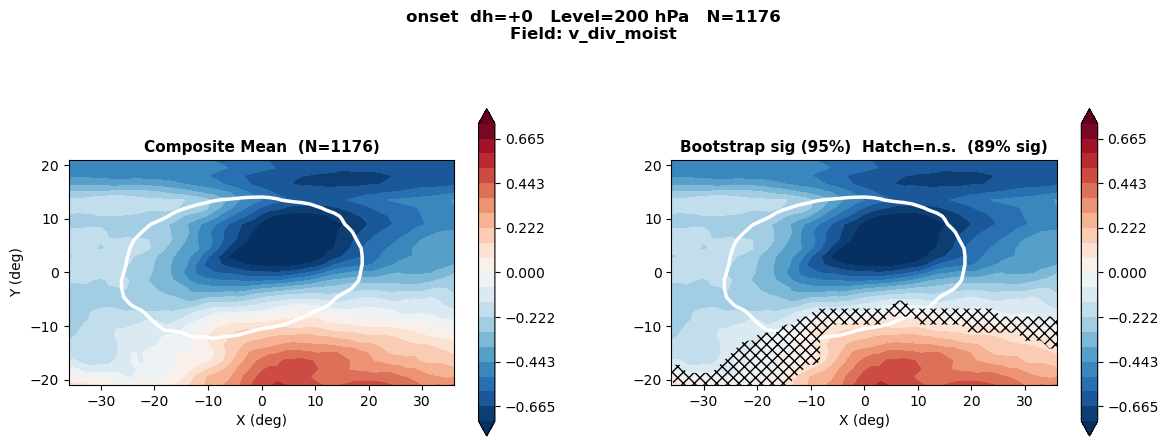

Computing bootstrap (N=1179, n_boot=500) ...
  83.8% significant at 95%


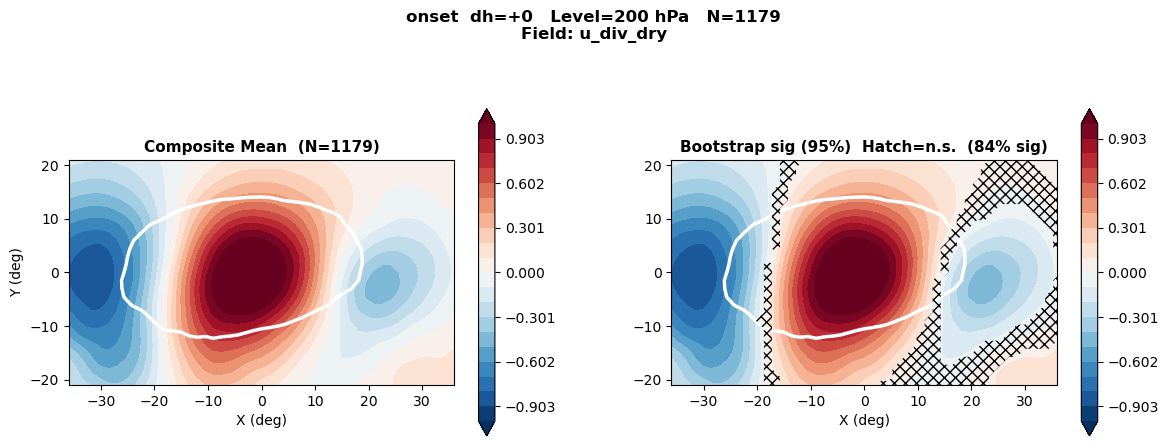

Computing bootstrap (N=1182, n_boot=500) ...
  89.4% significant at 95%


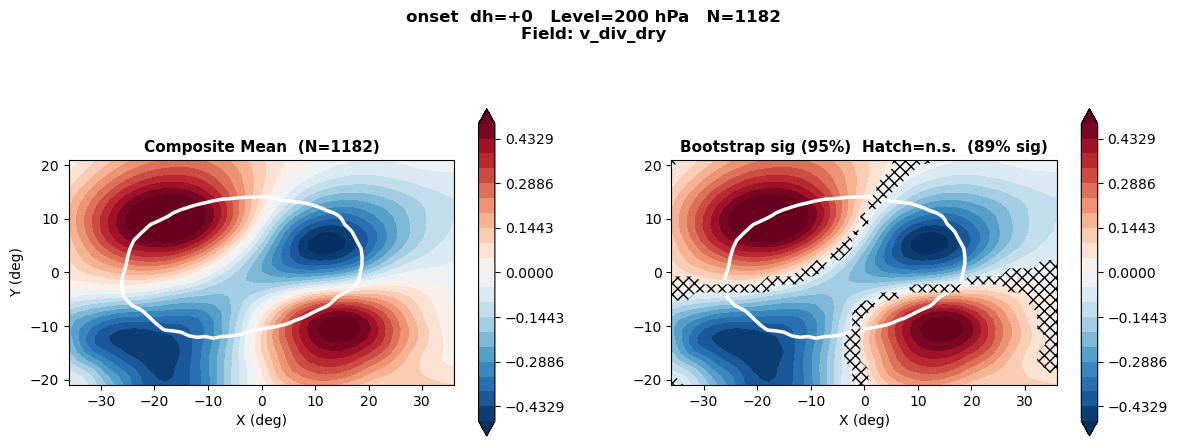

{'vmax': np.float32(0.48102054)}

In [8]:
# composite of individual divergent wind & PV gradient components
plot_var(["u_div_moist"], dh=0, level=200, projection=False)
plot_var(["v_div_moist"], dh=0, level=200, projection=False)
plot_var(["u_div_dry"], dh=0, level=200, projection=False)
plot_var(["v_div_dry"], dh=0, level=200, projection=False)

Computing bootstrap (N=1187, n_boot=500) ...
  100.0% significant at 95%


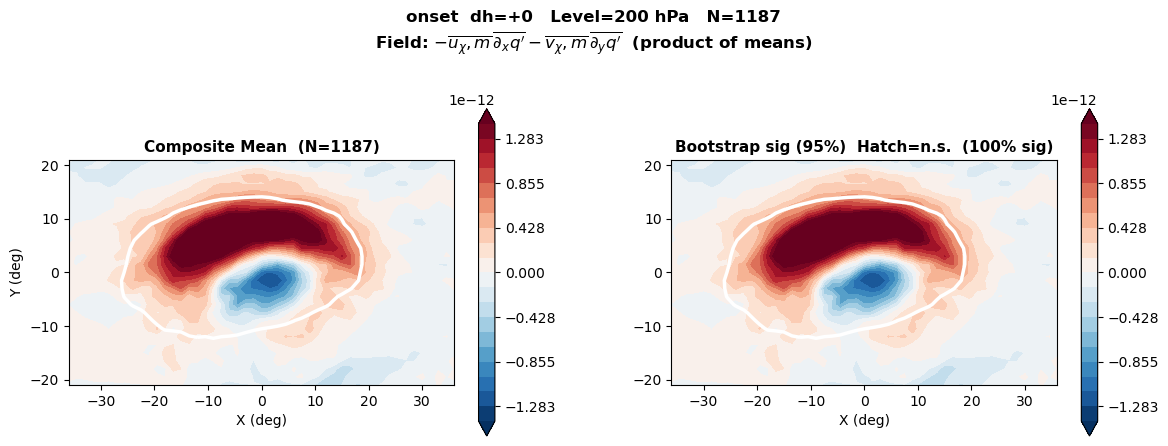

{'vmax': np.float64(1.4256906127740348e-12)}

In [9]:
# product-of-means: mean(u'_div) * mean(dq'/dx) + mean(v'_div) * mean(dq'/dy)
# differs from mean(u'_div * dq'/dx) by the covariance / eddy-eddy term
evs = load_events(dh=0)
_stack = lambda name: np.array([get_field(e, name, 200) for e in evs])
mean_u = np.nanmean(_stack("u_div_moist"), axis=0)
mean_v = np.nanmean(_stack("v_div_moist"), axis=0)
mean_dqdx = np.nanmean(_stack("pv_anom_dx"), axis=0)
mean_dqdy = np.nanmean(_stack("pv_anom_dy"), axis=0)
prod_of_means = -(mean_u * mean_dqdx + mean_v * mean_dqdy)

plot_var(
    lambda e: prod_of_means,   # constant — shows product-of-composite-means
    dh=0, level=200, projection=False,
    label=(r"$-\overline{u_\chi,m}\,\overline{\partial_x q'}"
           r" - \overline{v_\chi,m}\,\overline{\partial_y q'}$"
           "  (product of means)"),
)

Computing bootstrap (N=1189, n_boot=500) ...
  100.0% significant at 95%


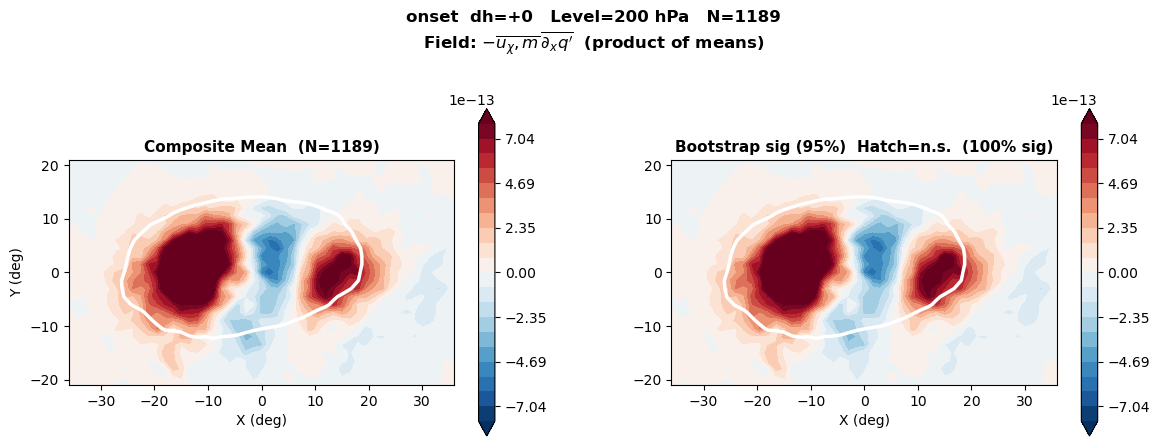

{'vmax': np.float64(7.816943197816497e-13)}

In [10]:
# product-of-means: x-component only
prod_of_means_x = -(mean_u * mean_dqdx)

plot_var(
    lambda e: prod_of_means_x,
    dh=0, level=200, projection=False,
    label=r"$-\overline{u_\chi,m}\,\overline{\partial_x q'}$  (product of means)",
)

Computing bootstrap (N=1189, n_boot=500) ...
  39.7% significant at 95%


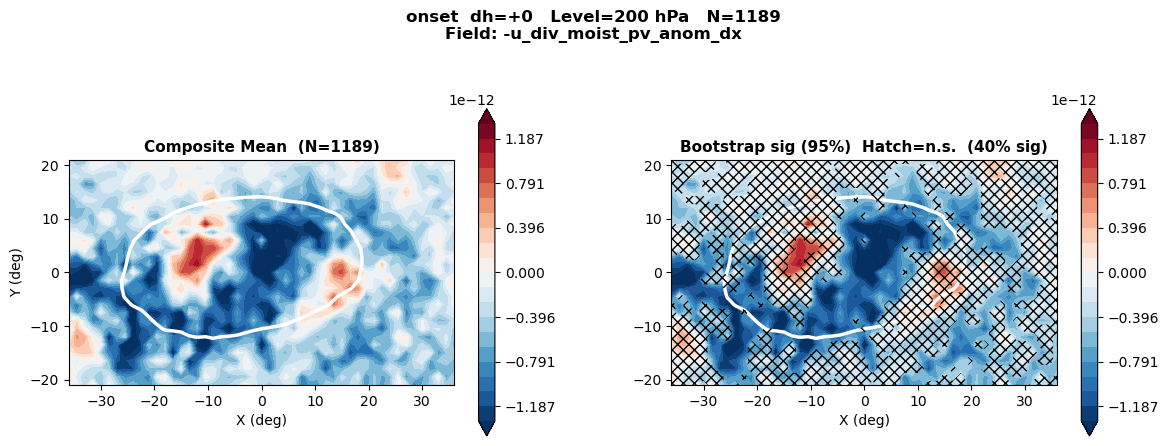

{'vmax': np.float64(1.3185723666662953e-12)}

In [11]:
# 6-panel: divergent outflow (no projection)
plot_var(["-u_div_moist_pv_anom_dx"], dh=0, level=200, projection=False)

Computing bootstrap (N=1191, n_boot=500) ...
  100.0% significant at 95%


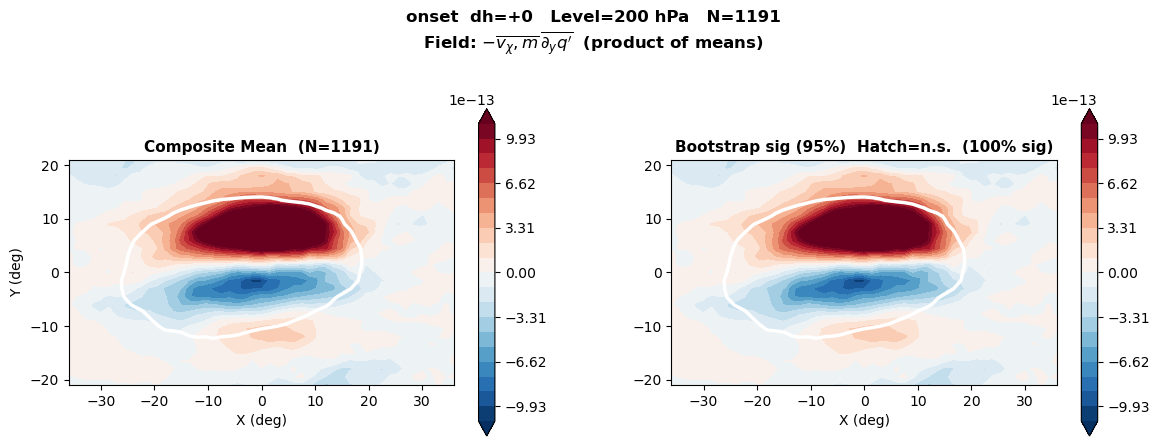

{'vmax': np.float64(1.1031796917318025e-12)}

In [12]:
# product-of-means: y-component only
prod_of_means_y = -(mean_v * mean_dqdy)

plot_var(
    lambda e: prod_of_means_y,
    dh=0, level=200, projection=False,
    label=r"$-\overline{v_\chi,m}\,\overline{\partial_y q'}$  (product of means)",
)

Computing bootstrap (N=1193, n_boot=500) ...
  36.9% significant at 95%


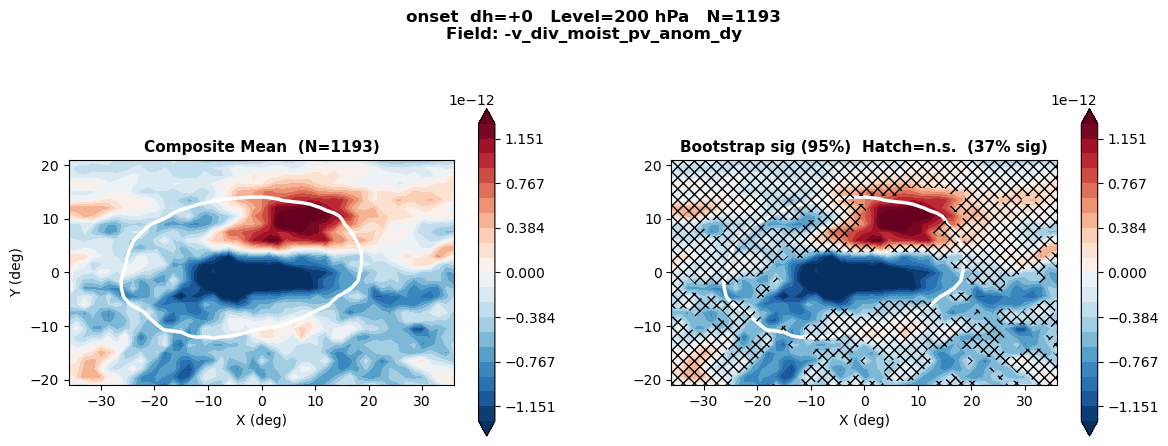

{'vmax': np.float64(1.2785934748325685e-12)}

In [13]:
# 6-panel: divergent outflow (no projection)
plot_var(["-v_div_moist_pv_anom_dy"], dh=0, level=200, projection=False)

Computing bootstrap (N=1195, n_boot=500) ...
  11.5% significant at 95%
  ⚠ dh=-1: skipped 1 corrupt/incomplete NPZ files
  Projection (sig-only): β=7.847e-07  αx=-0.102  αy=0.307  γ=-5.606e+05


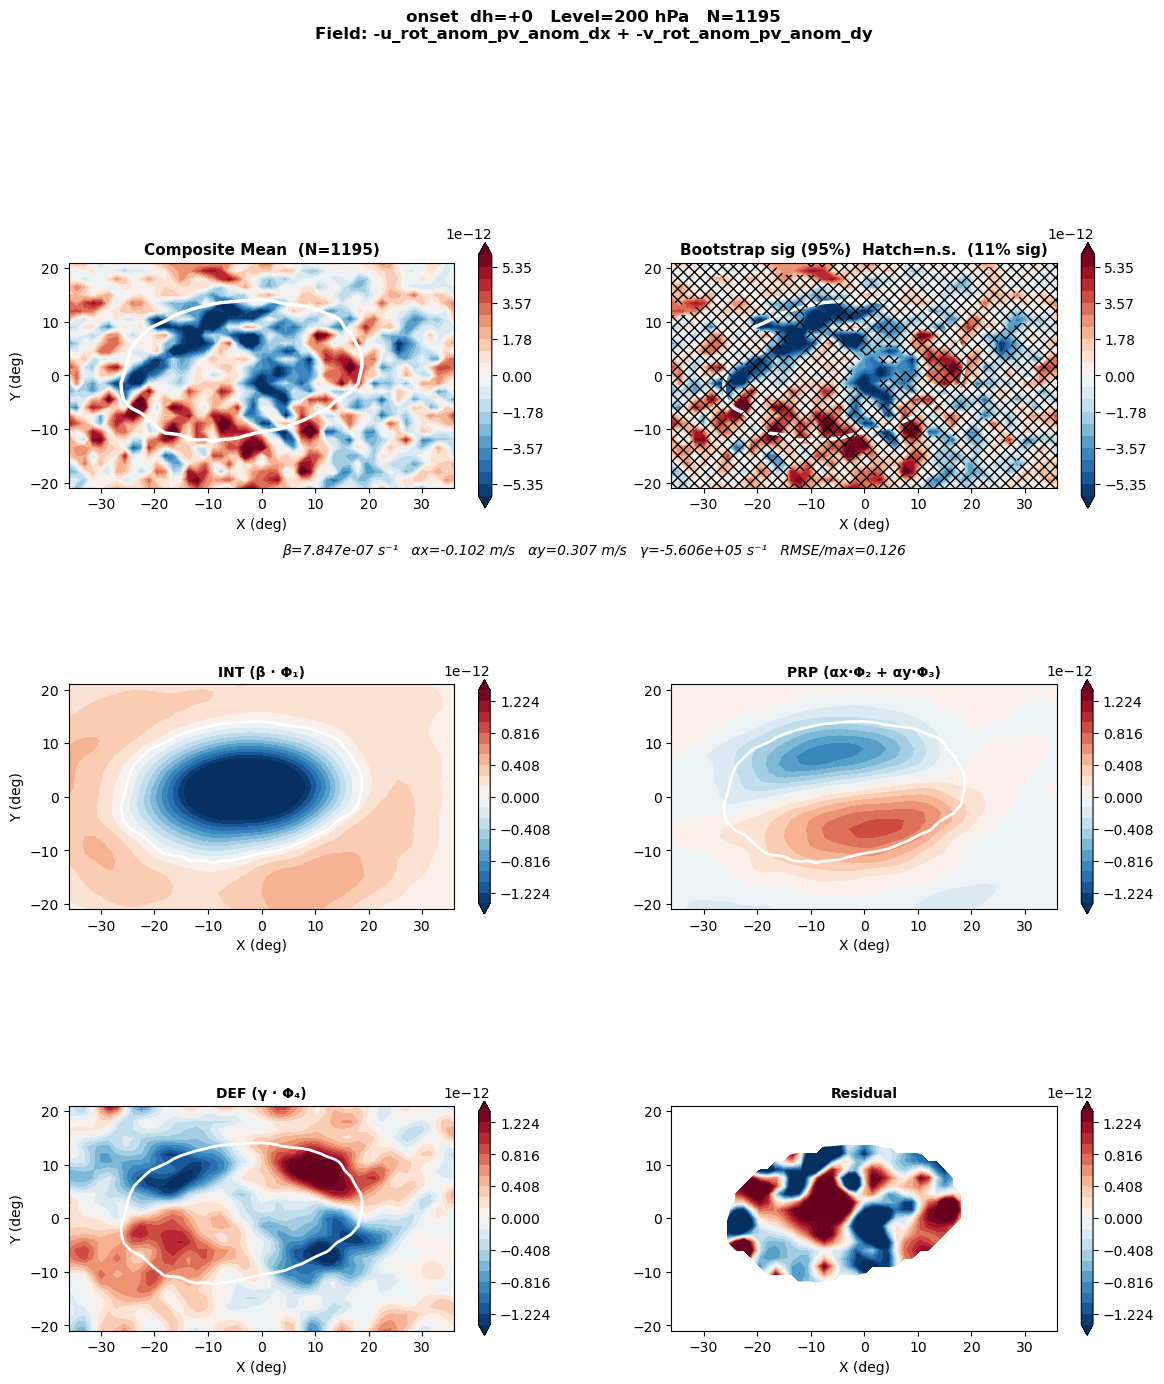

{'vmax': np.float64(5.949428273959404e-12),
 'beta': 7.847314798025934e-07,
 'ax': -0.1015242214324694,
 'ay': 0.3068288326501711,
 'gamma': -560597.5406134662,
 'gamma_km2': -0.5605975406134662,
 'beta_raw': 7.847314798025933e-13,
 'ax_raw': -1.0152422143246941e-13,
 'ay_raw': 3.0682883265017105e-13,
 'gamma_raw': -5.605975406134662e-13,
 'prop': array([[-8.68857208e-14, -1.13303855e-13, -1.43733430e-13, ...,
         -1.91178396e-14, -1.72363526e-14, -1.70314711e-14],
        [-7.09384066e-14, -9.43468818e-14, -1.32114016e-13, ...,
         -1.00278116e-14, -7.24673287e-15, -5.16129751e-15],
        [-4.02122443e-14, -5.37038029e-14, -8.26641728e-14, ...,
         -1.54598652e-14, -8.85929102e-15, -2.38031445e-15],
        ...,
        [ 9.23314324e-14,  1.01722067e-13,  1.12805851e-13, ...,
         -9.65752243e-15,  4.59883157e-17,  1.12042639e-14],
        [ 1.01679851e-13,  1.04365732e-13,  1.07508825e-13, ...,
          2.08388032e-14,  1.59932044e-14,  2.18958674e-14],
        

In [14]:
# 6-panel: rotational eddy advection
plot_var(["-u_rot_anom_pv_anom_dx", "-v_rot_anom_pv_anom_dy"], dh=0, level=200, projection=True)

Computing bootstrap (N=1198, n_boot=500) ...
  60.4% significant at 95%


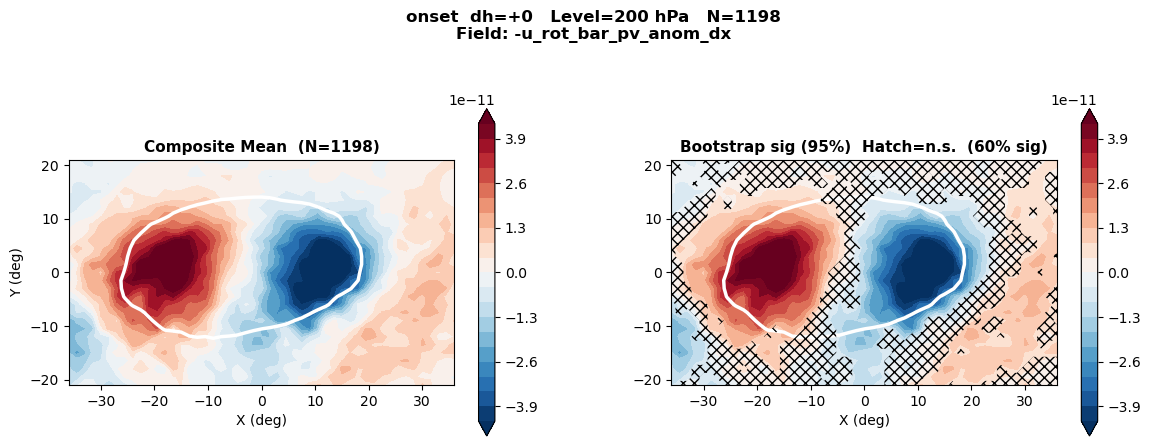

{'vmax': np.float64(4.332861690922065e-11)}

In [15]:
# 6-panel: rotational eddy advection
plot_var(["-u_rot_bar_pv_anom_dx"], dh=0, level=200, projection=False)

Computing bootstrap (N=1204, n_boot=500) ...
  12.0% significant at 95%


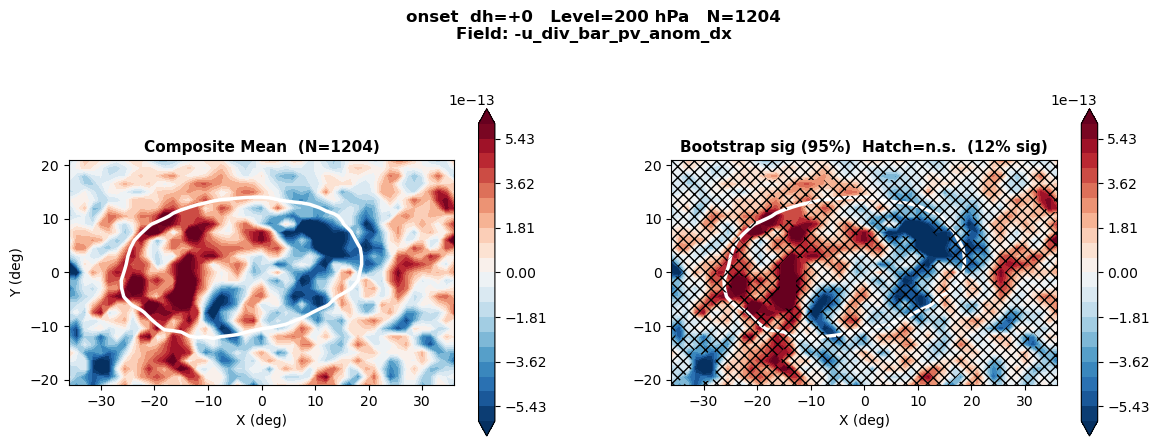

{'vmax': np.float64(6.028170383709334e-13)}

In [16]:
# 6-panel: rotational eddy advection
plot_var(["-u_div_bar_pv_anom_dx"], dh=0, level=200, projection=False)

Computing bootstrap (N=1205, n_boot=500) ...
  26.4% significant at 95%


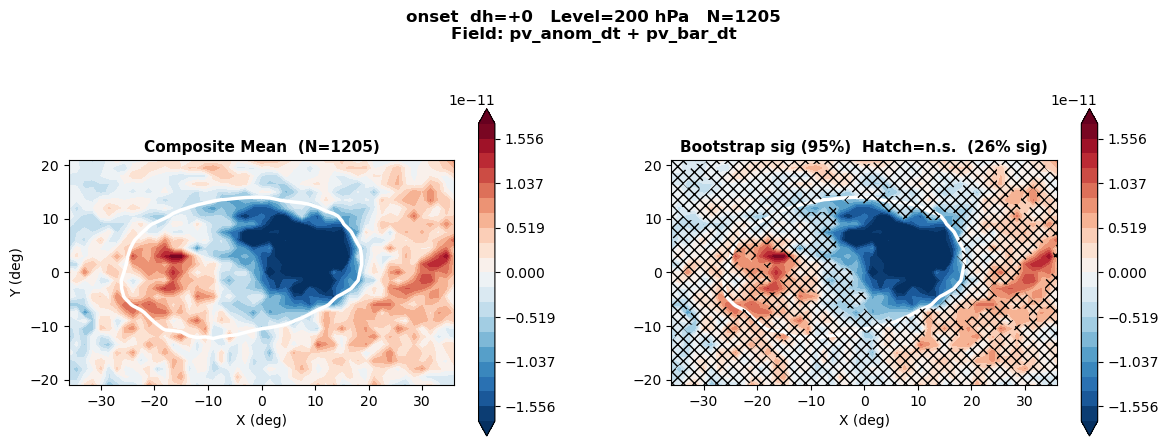

{'vmax': np.float64(1.7286494070074416e-11)}

In [17]:
# 2-panel: total tendency dq/dt (no projection)
plot_var(["pv_anom_dt", "pv_bar_dt"], dh=0, level = 200, projection=False)

Computing bootstrap (N=1206, n_boot=500) ...
  82.5% significant at 95%


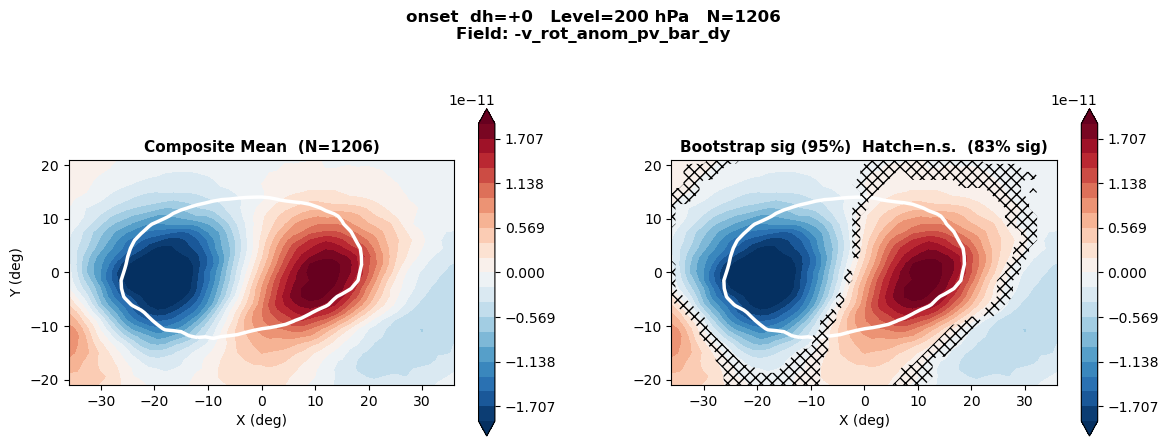

{'vmax': np.float64(1.8968734607289616e-11)}

In [18]:
# 6-panel: planetary vorticity advection
plot_var(["-v_rot_anom_pv_bar_dy"], dh=0, level=200, projection=False)

Computing bootstrap (N=1207, n_boot=500) ...
  79.0% significant at 95%


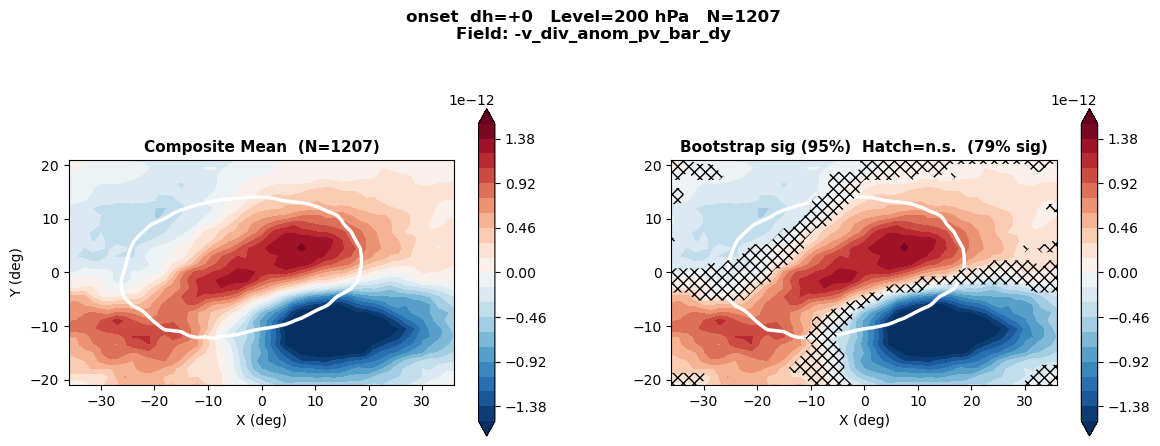

{'vmax': np.float64(1.5331994661984185e-12)}

In [19]:
# 6-panel: planetary vorticity advection
plot_var(["-v_div_anom_pv_bar_dy"], dh=0, level=200, projection=False)

Computing bootstrap (N=1207, n_boot=500) ...
  37.3% significant at 95%
  Projection (sig-only): β=3.171e-07  αx=-3.161  αy=0.350  γ=-6.119e+04


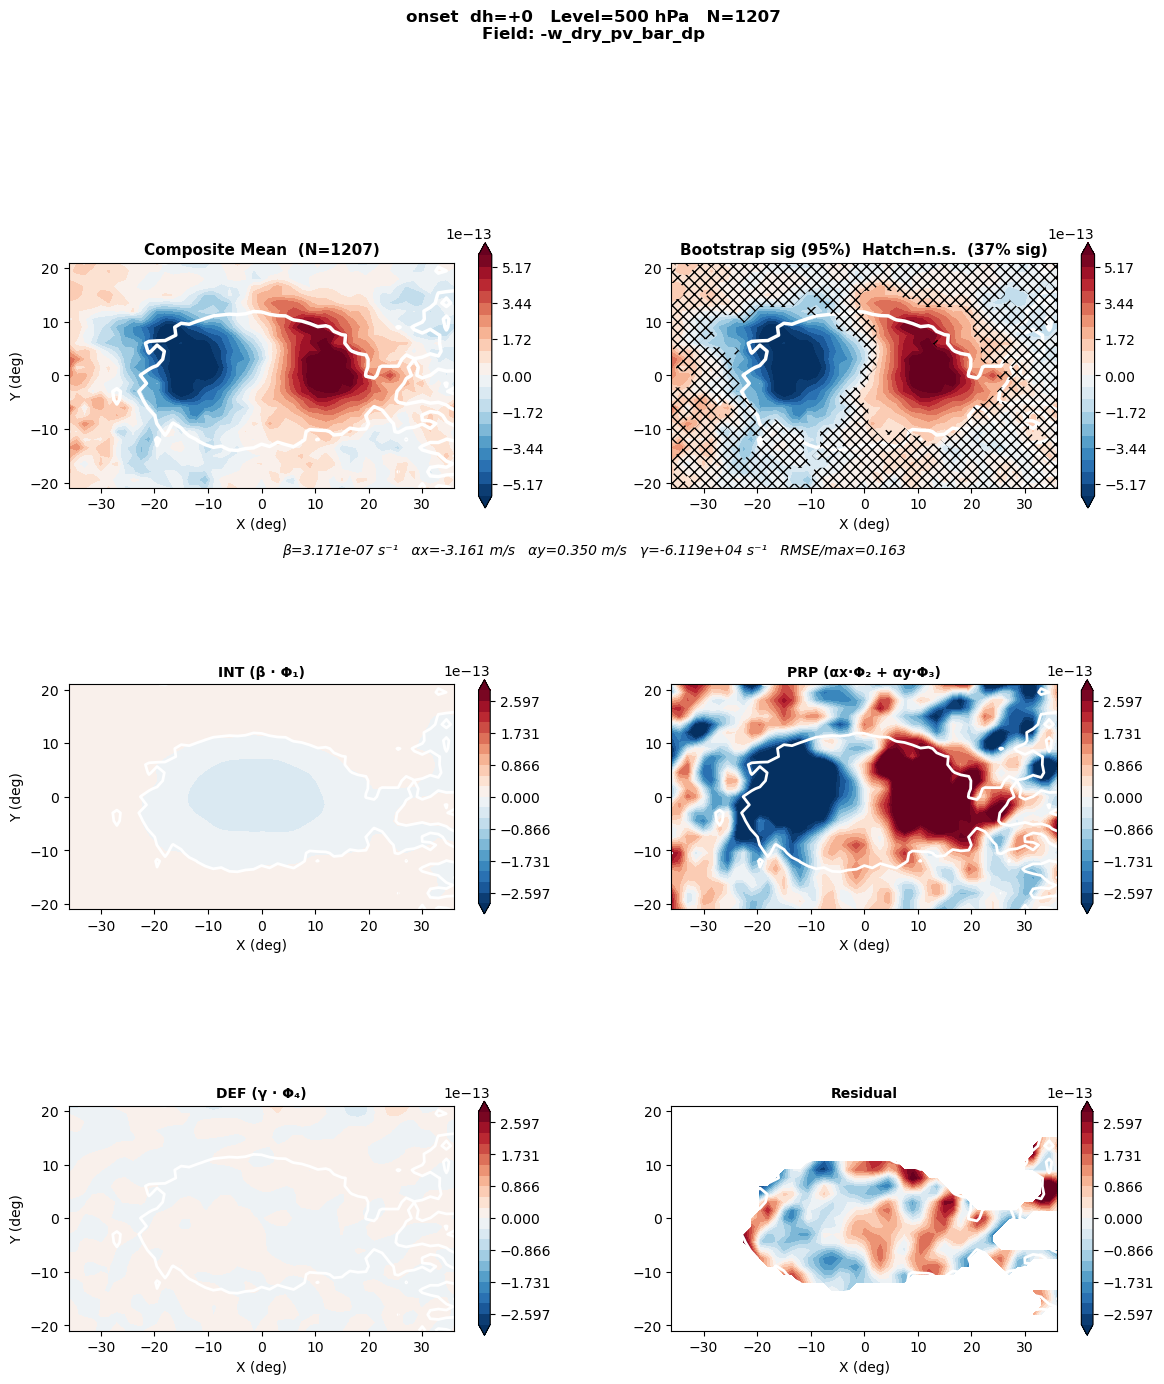

{'vmax': np.float64(5.739178439020383e-13),
 'beta': 3.170953900820078e-07,
 'ax': -3.161329832828103,
 'ay': 0.34976038677151666,
 'gamma': -61194.06688505115,
 'gamma_km2': -0.06119406688505115,
 'beta_raw': 3.170953900820078e-13,
 'ax_raw': -3.161329832828103e-12,
 'ay_raw': 3.4976038677151665e-13,
 'gamma_raw': -6.119406688505115e-14,
 'prop': array([[ 2.19906845e-13,  1.33166555e-13,  2.48464803e-14, ...,
         -1.22942910e-14, -2.61130073e-14, -1.89252421e-14],
        [ 2.45590382e-13,  8.83730866e-14, -5.75472141e-14, ...,
          3.81423916e-14,  2.67727737e-14, -9.96582339e-15],
        [ 2.06745708e-13,  9.58365170e-14, -4.16187784e-14, ...,
          1.95076105e-14,  6.45822339e-14,  1.16824235e-14],
        ...,
        [ 9.72492039e-14,  1.22222510e-13,  1.75616186e-13, ...,
         -1.62695586e-13, -3.06193752e-14,  7.40822899e-14],
        [-1.22146381e-13,  1.54933663e-14,  1.66937501e-13, ...,
         -2.02531398e-13, -5.75442591e-15,  1.20028910e-13],
        

In [20]:
plot_var(["-w_dry_pv_bar_dp"], dh=0, level=500, projection=True)

Computing bootstrap (N=1213, n_boot=500) ...
  10.4% significant at 95%
  Projection (sig-only): β=7.799e-08  αx=-0.190  αy=0.128  γ=3.399e+04


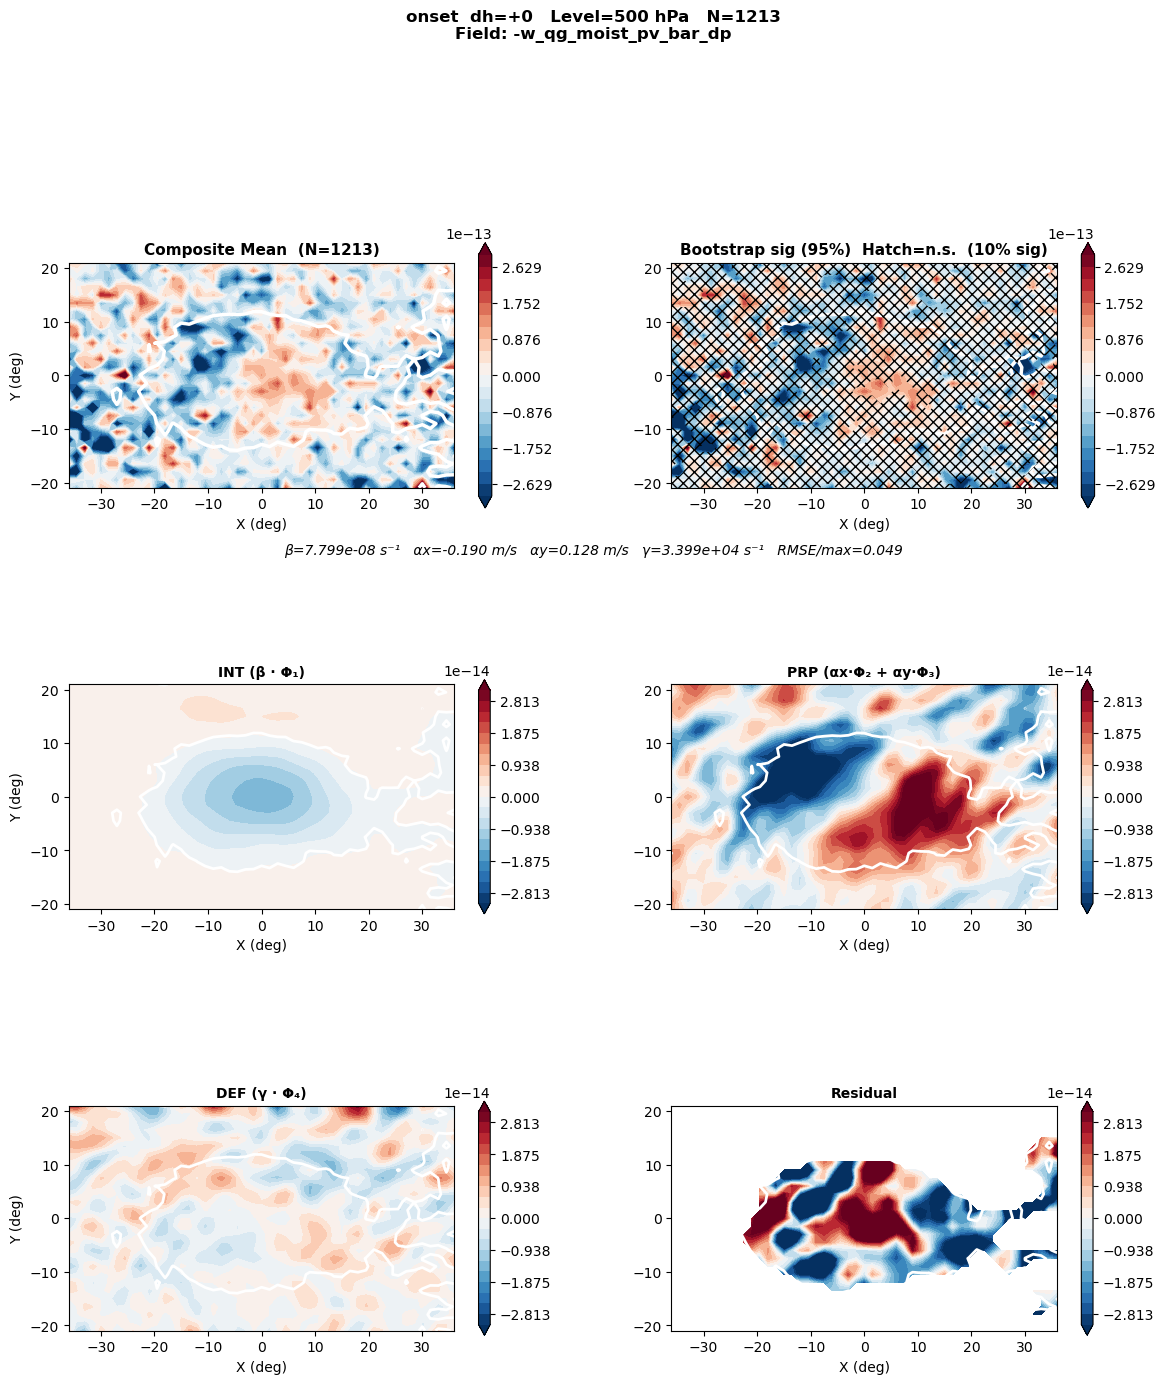

{'vmax': np.float64(2.9207260455106834e-13),
 'beta': 7.799209920330211e-08,
 'ax': -0.19018986617976386,
 'ay': 0.1280239601418067,
 'gamma': 33994.576443731414,
 'gamma_km2': 0.03399457644373141,
 'beta_raw': 7.799209920330211e-14,
 'ax_raw': -1.9018986617976386e-13,
 'ay_raw': 1.2802396014180668e-13,
 'gamma_raw': 3.399457644373141e-14,
 'prop': array([[ 1.11972792e-14,  5.55331396e-15,  3.85969282e-16, ...,
         -1.99469275e-15, -3.63172936e-15, -2.73903835e-15],
        [ 1.45723179e-14,  4.21886968e-15, -4.46225246e-15, ...,
          3.63410860e-15,  1.56400324e-15, -1.24401093e-15],
        [ 1.41687374e-14,  7.38869746e-15, -2.18221039e-15, ...,
          1.80777638e-15,  5.12542618e-15,  1.92213029e-15],
        ...,
        [ 8.18229164e-15,  1.10076600e-14,  1.51863676e-14, ...,
         -1.10196161e-14, -3.04061281e-15,  3.32178295e-15],
        [-1.57298163e-16,  7.29229205e-15,  1.56295960e-14, ...,
         -1.32110706e-14, -2.00911782e-15,  5.26637238e-15],
       

In [21]:
plot_var(["-w_qg_moist_pv_bar_dp"], dh=0, level=500, projection=True)